# Data Analysis

In [10]:
from __future__ import annotations

import os
from typing import Sequence
import plotly.io as pio
pio.renderers.default = "iframe"  # oppure "browser", "vscode" a seconda dell'editor
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import yaml
STROKE_TIME_COLS = ['D', 'mu', 'sigma', 'to']
STROKE_GEOM_COLS = ['start_x', 'start_y', 'start_z', 
                    'mid_x', 'mid_y', 'mid_z', 
                    'end_x', 'end_y', 'end_z']
PERFORMANCE_COLS = ['snr_t', 'snr_v']
ROOT_TO_SAMPLE_DIRS = ['subject', 'task', 'recording', 'stroke_number']

## Database Creation
Each row contains a single stroke. Each stroke can be grouped by:
* Recording
* Task
* Subject

Each stroke contains:
* Analytical characterization:
    * $D$ length param
    * $\log\sigma$ param
    * $\mu$ param
    * $t_0$ param
* Geometrical characterization:
    * $P_{start}$ Virtual target point corresponding to the start of the stroke
    * $P_{mid}$ Middle point that uniquely describes the arc of circumference
    * $P_{end}$ Virtual target point corresponding to the end of the stroke

In [11]:
def create_database(root:str) -> pd.DataFrame:
    """
    Create a database of stroke parameters from CSV files in the given root directory.

    Args:
        root (str): The root directory containing CSV files.
    Returns:
        database (pd.DataFrame): Dafaframe representation of the dataset
    """
    root_folder = os.path.abspath(os.path.join(os.getcwd(), root))
    records = []

    for subject_folder in os.listdir(root_folder):
        if not os.path.isdir(os.path.join(root_folder, subject_folder)):
            continue
        subject_name = os.path.basename(subject_folder)

        for task_folder in os.listdir(os.path.join(root_folder, subject_folder)):
            if not os.path.isdir(os.path.join(root_folder, subject_folder, task_folder)):
                continue
            task_name = os.path.basename(task_folder)

            for csv_file in os.listdir(os.path.join(root_folder, subject_folder, task_folder)):
                if os.path.isdir(os.path.join(root_folder, subject_folder, task_folder, csv_file)):
                    continue
                if csv_file.endswith('logn.csv'):
                    
                    csv_path = os.path.join(root_folder, subject_folder, task_folder, csv_file)
                    recording_number = int(os.path.basename(csv_file).split('_')[1])
                    stroke_data = pd.read_csv(csv_path)

                    for _, row in stroke_data.iterrows():
                        record = {
                            'subject': subject_name,
                            'task': task_name,
                            'recording': recording_number,
                            'stroke_number': int(row['stroke']),
                        }
                        for col in STROKE_TIME_COLS + STROKE_GEOM_COLS + PERFORMANCE_COLS:
                            record[col] = row[col]

                        records.append(record)
            

    return pd.DataFrame(records)

In [12]:
database = create_database('lognormal_database_unsmooth')
database_trimmed = create_database('lognormal_database_trimmed')
database['sigma'] = np.exp(database['sigma'])
database_trimmed['sigma'] = np.exp(database_trimmed['sigma'])

### Number of waypoints for each task

In [13]:
PATH_TO_PATHS_FILE = os.path.join(os.getcwd(), 'src', 'unisa_acg_ros2', 'haptics', 'haptic_interaction_teach_and_record_demo', 'config', 'paths.yaml')
if not os.path.exists(PATH_TO_PATHS_FILE):
    raise FileNotFoundError(f"Paths file not found: {PATH_TO_PATHS_FILE}")

WAYPOINTS_BY_TASK = {}
with open(PATH_TO_PATHS_FILE, 'r') as f:
    paths_data = yaml.safe_load(f)
    print(f"Loaded paths data: {paths_data['paths']}")
    for path in paths_data['paths']:
        WAYPOINTS_BY_TASK[path['name']] = len(path['waypoints'])

WAYPOINTS_BY_TASK

Loaded paths data: [{'name': 'BURSTs_XY', 'waypoints': [{'x': 0.2, 'y': 0.2, 'z': 0.5}, {'x': 0.8, 'y': 0.8, 'z': 0.5}]}, {'name': 'BURSTs_XZ', 'waypoints': [{'x': 0.2, 'y': 0.5, 'z': 0.2}, {'x': 0.8, 'y': 0.5, 'z': 0.8}]}, {'name': 'BURSTs_YZ', 'waypoints': [{'x': 0.5, 'y': 0.2, 'z': 0.2}, {'x': 0.5, 'y': 0.8, 'z': 0.8}]}, {'name': 'BURSTs_3D', 'waypoints': [{'x': 0.15, 'y': 0.15, 'z': 0.15}, {'x': 0.85, 'y': 0.85, 'z': 0.85}]}, {'name': 'BURSTc_XY', 'waypoints': [{'x': 0.1, 'y': 0.2, 'z': 0.5}, {'x': 0.9, 'y': 0.5, 'z': 0.5}, {'x': 0.1, 'y': 0.8, 'z': 0.5}]}, {'name': 'BURSTc_XZ', 'waypoints': [{'x': 0.2, 'y': 0.5, 'z': 0.1}, {'x': 0.5, 'y': 0.5, 'z': 0.9}, {'x': 0.8, 'y': 0.5, 'z': 0.1}]}, {'name': 'BURSTc_YZ', 'waypoints': [{'x': 0.5, 'y': 0.1, 'z': 0.2}, {'x': 0.5, 'y': 0.9, 'z': 0.5}, {'x': 0.5, 'y': 0.1, 'z': 0.8}]}, {'name': 'REVERSAL_X', 'waypoints': [{'x': 0.15, 'y': 0.5, 'z': 0.5}, {'x': 0.85, 'y': 0.5, 'z': 0.5}, {'x': 0.15, 'y': 0.55, 'z': 0.5}]}, {'name': 'REVERSAL_Z', 'w

{'BURSTs_XY': 2,
 'BURSTs_XZ': 2,
 'BURSTs_YZ': 2,
 'BURSTs_3D': 2,
 'BURSTc_XY': 3,
 'BURSTc_XZ': 3,
 'BURSTc_YZ': 3,
 'REVERSAL_X': 3,
 'REVERSAL_Z': 3,
 'REVERSAL_3D': 3,
 'CHEVRON_XY': 3,
 'CHEVRON_XZ': 3,
 'CARET_XY': 3,
 'CARET_YZ': 3,
 'CHECK_XY': 3,
 'CHECK_XZ': 3,
 'HOOK_XY': 3,
 'HOOK_YZ': 3,
 'LETTER_S': 4,
 'LETTER_Z': 4,
 'LETTER_N': 4,
 'TRIANGLE_XY': 4,
 'ZIGZAG_W_XY': 4,
 'ZIGZAG_W_XZ': 4,
 'ZIGZAG_W_YZ': 4,
 'RECIPROCAL_Z': 4}

### \[TODO\] Drop unavailable tasks

In [14]:
TASKS_TO_DROP = []
TASKS_TO_DROP = ['LETTER2_PHI'] + sorted(
    set(WAYPOINTS_BY_TASK.keys()) - set(database.loc[database['subject'] == 'NOEMI_BIANCAMANO', 'task'])
)

database = database[~database['task'].isin(TASKS_TO_DROP)]
database = database.reset_index(drop=True)

database_trimmed = database_trimmed[~database_trimmed['task'].isin(TASKS_TO_DROP)]
database_trimmed = database_trimmed.reset_index(drop=True)

In [15]:
TASKS = database['task'].unique()

for task in TASKS:
    print(f"Task: {task}, samples: ", database[database['task'] == task].shape[0])

Task: GEOMETRIC6_ELLIPSE_XY, samples:  174
Task: LETTER1_L, samples:  88
Task: GEOMETRIC1_SPIRAL_3DY, samples:  225
Task: GEOMETRIC4_CIRCLE_XY, samples:  270
Task: GEOMETRIC5_CIRCLE_ZX, samples:  266
Task: LETTER4_N, samples:  90
Task: GEOMETRIC7_ELLIPSE_XZ, samples:  110
Task: BURST5_XZ, samples:  219
Task: LETTER3_S, samples:  83
Task: GEOMETRIC3_SPIRAL_XY, samples:  255
Task: BURST6_YZ, samples:  209
Task: GEOMETRIC2_SPIRAL_3DX, samples:  215
Task: BURST4_XY, samples:  187
Task: BURST3_YZ, samples:  169
Task: BURST1_XY, samples:  190
Task: BURST2_XZ, samples:  183


## Data Overview

In [16]:
SUBJECTS = database['subject'].unique()

for subject in SUBJECTS:
    print(f"Subject: {subject}, samples: ", database[database['subject'] == subject].shape[0])

for subject in SUBJECTS:
    print(f"Subject: {subject}, samples: ", database_trimmed[database_trimmed['subject'] == subject].shape[0])


len(database), len(database_trimmed)

Subject: LUCIA_DE_LUCIA, samples:  1355
Subject: NOEMI_BIANCAMANO, samples:  843
Subject: DAVIDE_DACUNTO, samples:  735
Subject: LUCIA_DE_LUCIA, samples:  1108
Subject: NOEMI_BIANCAMANO, samples:  15
Subject: DAVIDE_DACUNTO, samples:  704


(2933, 1827)

### Compare lognormal parametrs distributions among datasets

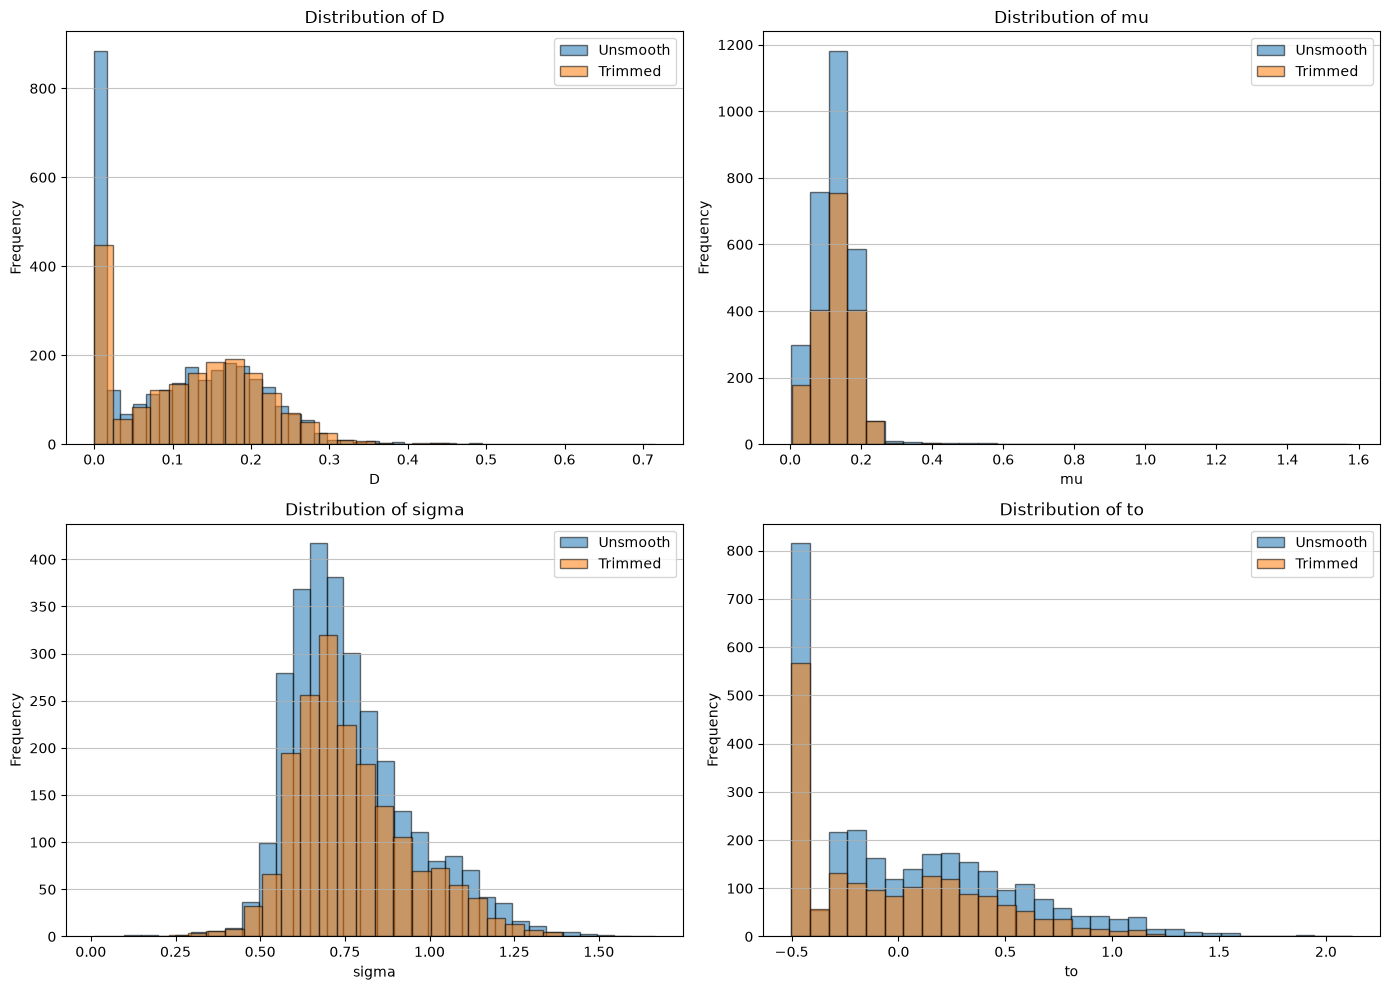

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for ax, col in zip(axes, STROKE_TIME_COLS):
    ax.hist(
        database[col].dropna(),
        bins=30,
        alpha=0.55,
        color='tab:blue',
        edgecolor='black',
        label='Unsmooth'
    )
    ax.hist(
        database_trimmed[col].dropna(),
        bins=30,
        alpha=0.55,
        color='tab:orange',
        edgecolor='black',
        label='Trimmed'
    )

    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.grid(axis='y', alpha=0.75)
    ax.legend()

plt.tight_layout()
plt.show()

### Stroke Count by task

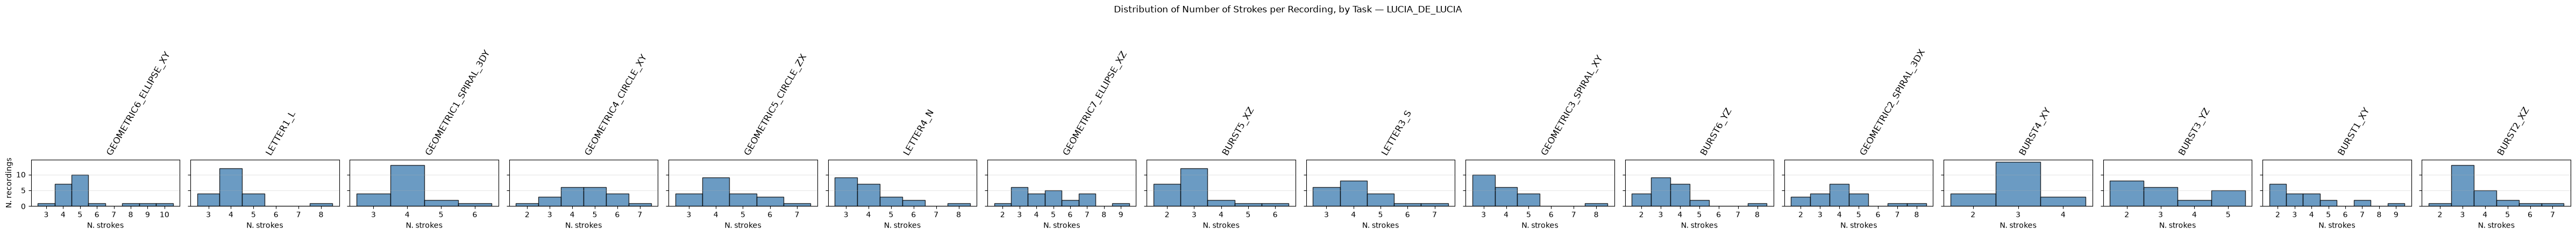

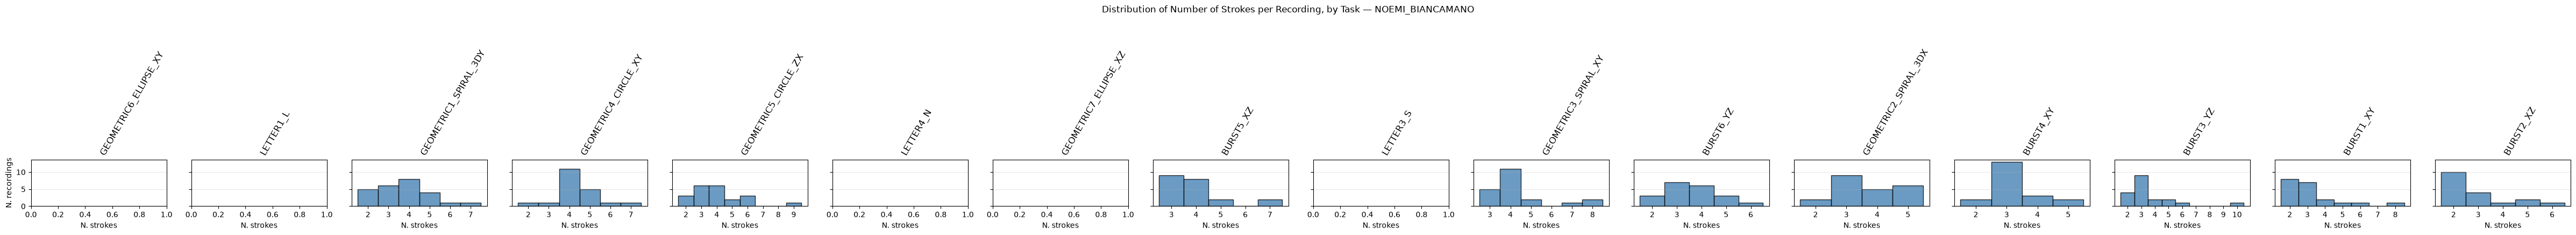

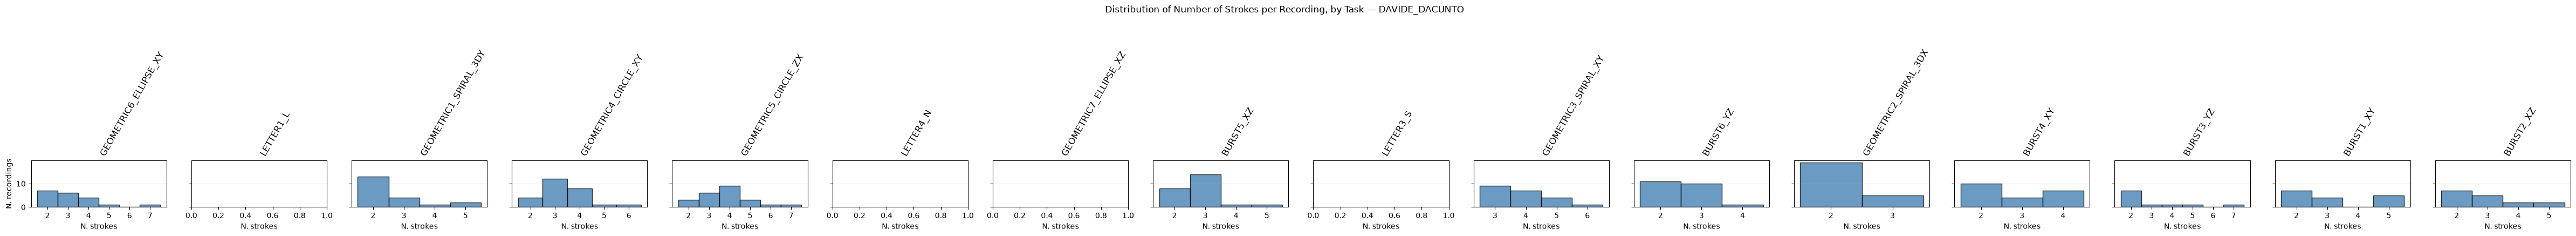

In [18]:
recording_stroke_counts = (
    database
    .groupby(['subject', 'task', 'recording'])
    .size()
    .reset_index(name='stroke_count')
)

for subject in SUBJECTS:
    subject_data = recording_stroke_counts[recording_stroke_counts['subject'] == subject]

    fig, axes = plt.subplots(
        1, len(TASKS),
        figsize=(3 * len(TASKS), 4),
        sharey=True,
        squeeze=False
    )
    axes = axes[0]

    for task_idx, task in enumerate(TASKS):
        ax = axes[task_idx]
        task_counts = subject_data.loc[subject_data['task'] == task, 'stroke_count']

        if len(task_counts) > 0:
            bins = np.arange(task_counts.min(), task_counts.max() + 2) - 0.5
            ax.hist(task_counts, bins=bins, color='steelblue', edgecolor='black', alpha=0.8)
            ax.set_xticks(range(int(task_counts.min()), int(task_counts.max()) + 1))

        ax.set_title(task, rotation=60, ha='left')
        ax.set_xlabel('N. strokes')
        ax.grid(axis='y', alpha=0.3)

    axes[0].set_ylabel('N. recordings')
    plt.suptitle(f'Distribution of Number of Strokes per Recording, by Task — {subject}', y=1.08)
    plt.tight_layout()
    plt.show()


In [32]:
recording_stroke_counts = (
    database_trimmed
    .groupby(['subject', 'task', 'recording'])['stroke_number']
    .count()
    .reset_index(name='stroke_count')
)
recording_stroke_counts.sort_values(by=['stroke_count'], ascending=False).head(50)

,subject,task,recording,stroke_count
201,DAVIDE_DACUNTO,GEOMETRIC5_CIRCLE_ZX,1,8
494,LUCIA_DE_LUCIA,GEOMETRIC7_ELLIPSE_XZ,20,7
382,LUCIA_DE_LUCIA,GEOMETRIC2_SPIRAL_3DX,12,7
477,LUCIA_DE_LUCIA,GEOMETRIC7_ELLIPSE_XZ,3,7
409,LUCIA_DE_LUCIA,GEOMETRIC3_SPIRAL_XY,19,7
547,LUCIA_DE_LUCIA,LETTER4_N,9,7
328,LUCIA_DE_LUCIA,BURST6_YZ,0,7
436,LUCIA_DE_LUCIA,GEOMETRIC5_CIRCLE_ZX,5,6
543,LUCIA_DE_LUCIA,LETTER4_N,5,6
496,LUCIA_DE_LUCIA,GEOMETRIC7_ELLIPSE_XZ,22,6
